# Justify the 2Dmesh remeshing parameters used in MeshPipeline

In [2]:
import os
print(os.getcwd())

/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/notebooks/MeshPipeline/BonePrep/RemeshJustification


In [24]:
import subprocess
import numpy as np
import pyvista as pv

from phd_helpers.paths import identical_points_count

### Switched grad_width to use Euclidean distance instead of geodesic distance so that it better reflects the 3Dmesh logic
 - Ensures that 2Dmesh transition region fully covers the 3Dmesh transition region, so that the 3D mesh is more refined everywhere than the 3Dmesh so that 3D element quality is not limited by 2Dmesh input and facet distance combination.
 - If input is smoother then it gives more flexibility for 3D element position / orientation. -  I think?
 - At least it should ensure the 3D mesh is trying to more closely replicate the "true" mesh surface rather than flat edges imposed by a coarse 2Dmesh input.

#### Verifying that it worked:

In [44]:
path_MeshPipeline_main = '../../../../MeshPipeline/main.py'
subprocess.run(["python", path_MeshPipeline_main])


Updating parameters.json
	Wrote /Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/MeshPipeline/set_parameters/parameters.json



SUBJECT: 14548R
	BONES: tpm-mc1
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 5.129s - ok
		STEP: cartilage
			RUN ID: -0-0
			Runtime: 5.864s - ok


CompletedProcess(args=['python', '../../../../MeshPipeline/main.py'], returncode=0)

In [ ]:
out_root = 'outputs/grad_width_test'

# before - geodesic distance
old_remesh = pv.read(f'{out_root}/meshes/14548R/tpm-mc1/2Dmesh/bone_remesh-0-before.obj')
# after - Euclidean distance
new_remesh = pv.read(f'{out_root}/meshes/14548R/tpm-mc1/2Dmesh/bone_remesh-0.obj')

In [46]:
# after changing to Euclidean distance - visually very similar, due to nature of geometry, but not identical
print('Mesh has changed:', identical_points_count(new_remesh.points,  old_remesh.points) != new_remesh.n_points)
old_remesh.plot()
new_remesh.plot()

Mesh has changed: True


Widget(value='<iframe src="http://localhost:64735/index.html?ui=P_0x332c73a40_15&reconnect=auto" class="pyvist…

Widget(value='<iframe src="http://localhost:64735/index.html?ui=P_0x332c70380_16&reconnect=auto" class="pyvist…

In [ ]:
check_cartilage = pv.read(f'{out_root}/meshes/14548R/tpm-mc1/2Dmesh/bone_cartilage_mesh-0-0.vtp')
check_cartilage.plot()

Widget(value='<iframe src="http://localhost:64735/index.html?ui=P_0x332cb7950_14&reconnect=auto" class="pyvist…

# Justify fine_edge_length
 - get cartilage height field for different fine_edge_lengths then mesh and measure rmse of next field?
    - also curvature or normal direction in set locations?
 - start with original mesh

 - check if subdivide to 0.3 influences cartilage height field
     - If influence is negligable then justify not doing it. Beacuse this is very fine detail so irrelevant unless it affects actual contact surface, which is cartilage
     - If negligable, should just be in appendix with the other approaches considered

 - Do it for all CMC TPM and MC1


 - Should measure RMSD of remeshed bone from input for each remesh to confirm it is not deviating
 - Should also measure height of cartilage height field to show its not deviating
 - All we are looking for is convergence of the height field to itself provided the above 2 points are true

Show that convergence of height field affects both smoothness and element quality of tets? Or just stick to the "assume it's is important cos full sensitivity / optimisation study is too much" and aim for convergence to true non discretised field?

In [8]:
import numpy as np
import pandas as pd
import pyvista as pv

from phd_helpers.CartilageGeneration import get_min_df_fast, get_triangle_adjacency, flood_fill_cells, fill_holes_pmf
from phd_helpers.paths import get_task_stl_paths, get_subject_stl_path, get_mesh, get_boundary

### Method development

In [ ]:
stl_paths = get_task_stl_paths('CMC')

poses = ['adduction','abduction','flexion','extension','pinch','grasp','jar','neutral']
bone, arbone = 'tpm', 'mc1'
subject, sideL = '14548', 'R'
stl_path = get_subject_stl_path(subject, sideL)

mesh = get_mesh(stl_path, bone)
armesh = get_mesh(stl_path, arbone)

In [438]:
print(FELs)

[0.6, 0.424, 0.3, 0.212, 0.15, 0.106, 0.075]


In [ ]:
output_root = 'outputs/cartilage_height_field'

subject, sideL = '14613', 'R'
bone, arbone = 'mc1', 'tpm'
stl_path = get_subject_stl_path(subject, sideL)
run_id = '-2'

mesh = pv.read(f'{output_root}/meshes/{subject}{sideL}/{bone}-{arbone}/2Dmesh/bone_remesh{run_id}.obj')
armesh = pv.read(f'{output_root}/meshes/{subject}{sideL}/{arbone}-{bone}/2Dmesh/bone_remesh{run_id}.obj')

#### Generate field mesh

In [220]:

min_df = get_min_df_fast(stl_path, bone, arbone, mesh, armesh, poses, 2)
midpoints = np.array(min_df['midpoint'].tolist()) # height field


In [221]:
# remove any points that arn't part of full triangle
mesh['point_id'] = np.arange(mesh.n_points)
field_surf = mesh.extract_points(min_df['bone_id'].values, adjacent_cells=False)
field_surf['surf_id'] = np.arange(field_surf.n_points)
field_mask = np.isin(min_df['bone_id'], field_surf['point_id'])
field = midpoints[field_mask]
# get boundary lines for height field
field_bound = get_boundary(field_surf)
field_bound.points = field[field_bound['surf_id']]

In [222]:
# check boundary lines
pl = pv.Plotter()
pl.add_mesh(mesh, color='white')
pl.add_points(field, point_size=10)
pl.add_mesh(field_bound, color='red', line_width=5)
pl.show()

Context leak detected, CoreAnalytics returned false


Widget(value='<iframe src="http://localhost:53297/index.html?ui=P_0x35c9afa10_65&reconnect=auto" class="pyvist…

In [223]:
# mesh field
field_mesh = pv.PolyData(np.vstack( (field_bound.points, field) ), lines=field_bound.lines)
field_mesh = field_mesh.delaunay_2d(edge_source=field_bound, alpha=0.85).triangulate().remove_unused_points()
field_mesh = field_mesh.fill_holes(field_mesh.area/20)


In [224]:
# check delaunay mesh
pl = pv.Plotter()
pl.add_mesh(field_mesh, show_edges=True)
pl.add_mesh(field_bound, color='red', line_width=5)
#pl.add_points(field, point_size=10, color='cyan')
pl.show()

Widget(value='<iframe src="http://localhost:53297/index.html?ui=P_0x381ebc920_66&reconnect=auto" class="pyvist…

In [225]:

# remove cells that lie outside of the boundary lines
edge_map, adjacency = get_triangle_adjacency(field_mesh)
#start_face = field_mesh.find_closest_cell(np.mean(field_mesh.points, axis=0))
start_face = field_mesh.find_closest_cell(field_mesh.center)
inner_cells = flood_fill_cells(field_mesh, start_face, field_bound.lines.reshape(-1, 3)[:, 1:], adjacency)
field_mesh_clean = pv.PolyData(field_mesh.points, field_mesh.faces.reshape(-1, 4)[inner_cells]).remove_unused_points()


In [226]:
from scipy.spatial.distance import cdist

dists = cdist(field_mesh_clean.points, field_bound.points)
inner_mask = np.min(dists, axis=1) > 0.5

dists = cdist(field_mesh_clean.points, midpoints)
field_mesh_clean['heights'] = min_df['dist'].iloc[np.argmin(dists, axis=1)]

In [227]:
# check final field mesh
pl = pv.Plotter()
pl.add_mesh(mesh, color='gray', opacity=0.5)
pl.add_mesh(field_mesh_clean, show_edges=True, color='white')
#pl.add_mesh(field_mesh_clean3, show_edges=True, color='beige')
pl.add_mesh(field_bound, color='red', line_width=5)
pl.add_points(field_mesh.cell_centers().points[start_face], color='cyan', point_size=10)
#pl.add_points(field, point_size=5, color='cyan')
#pl.add_points(field_mesh_clean.points[inner_mask], point_size=5, color='magenta')
pl.show()

Widget(value='<iframe src="http://localhost:53297/index.html?ui=P_0x382077c20_67&reconnect=auto" class="pyvist…

#### Compute metrics
 - RMSD of field from bone surface (shouldn't change much)
 - RMSD of remeshed bone from smoothed bone (shouldn't change much)
 - RMSD of field to previous field - use field_mesh points (should converge)

In [26]:
def compute_rmsd(mesh, points):
    _, ps = mesh.find_closest_cell(points, return_closest_point=True)
    dists = np.linalg.norm(points - ps, axis=1)
    return np.sqrt(np.mean(dists**2))

In [ ]:
prev_field = field_mesh

rmsd_f2b = compute_rmsd(mesh, field_mesh.points) # current field_mesh to current bone_mesh (no change?)
rmsd_b2b = compute_rmsd(mesh, mesh.points) # current bone_mesh to smooth bone_mesh (no change?)
rmsd_f2f = compute_rmsd(prev_field, field_mesh.points) # current field_mesh to previous field_mesh (converge?)

print(rmsd_b2b, rmsd_f2b, rmsd_f2f)

0.0 0.49114876530514145 0.0


#### Remesh bones
 - Remesh to chosen target edge length in cartilage region
 - leave edge size elsewhere as whatever for now, doesn't affect size field.
     - but will have to consider the effect edge size elsewhere has on computation time and 3Dmesh at some point

#### Choose fine_edge_lengths

In [44]:
# start at 0.3 and double cells each time
L = 0.6
n_halfs = 7
print('fine_edge_lengths:\n\t', [round(float(L/(np.sqrt(2)**x)), 3) for x in range(n_halfs)])
print(f'n cells ~ \n\t{[10000*2**x for x in range(n_halfs)]}')

fine_edge_lengths:
	 [0.6, 0.424, 0.3, 0.212, 0.15, 0.106, 0.075]
n cells ~ 
	[10000, 20000, 40000, 80000, 160000, 320000, 640000]


Parameters.py are set to run 2Dmesh for:
- all CMC subjects
- tpm-mc1 (remesh_arbone = True)
- coarse_edge_length = 1 (should be irrelavant but setting fairly coarse for computational speed)
- grad_width = 2 (should be irrelavant but setting fairly thin for computational speed)
- max_gap_remesh = 2.5 (to be cautious - ensures entire 2mm region is contained)
- adjacent_cells = True (to be cautious)

In [ ]:
stl_paths = get_task_stl_paths('CMC')
subs = [x.parent.name for x in stl_paths]
sides = [x.name[0] for x in stl_paths]
print([x + y for x, y in zip(subs, sides)])

['50037L', '50090R', '15294R', '50053R', '50049R', '15737R', '50061R', '14726R', '50016L', '14613R', '15358R', '50008L', '16276L', '15441R', '50024R', '14874R', '22306R', '14727R', '50033L', '15284R', '50017L', '50029R', '50027L', '50018L', '15357R', '50001R', '15006R', '14819R', '14873R', '50034R', '15283R', '50021R', '50019R', '15285R', '50020R', '50006R', '50000R', '50007L', '50014R', '14827L', '14818R', '14548R', '15882R', '15282R', '50045R', '14685R']


In [48]:
import subprocess
path_MeshPipeline_main = '../../../../MeshPipeline/main.py'
subprocess.run(["python", path_MeshPipeline_main])


Updating parameters.json
	Wrote /Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/MeshPipeline/set_parameters/parameters.json



SUBJECT: 50037L
	BONES: tpm-mc1
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 6.396s - ok
			RUN ID: -1
			Runtime: 6.580s - ok
			RUN ID: -2
			Runtime: 6.640s - ok
			RUN ID: -3
			Runtime: 6.814s - ok
			RUN ID: -4
			Runtime: 7.135s - ok
			RUN ID: -5
			Runtime: 7.958s - ok
			RUN ID: -6
			Runtime: 9.229s - ok

SUBJECT: 50090R
	BONES: tpm-mc1
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 5.450s - ok
			RUN ID: -1
			Runtime: 5.449s - ok
			RUN ID: -2
			Runtime: 5.400s - ok
			RUN ID: -3
			Runtime: 5.603s - ok
			RUN ID: -4
			Runtime: 5.997s - ok
			RUN ID: -5
			Runtime: 6.628s - ok
			RUN ID: -6
			Runtime: 7.898s - ok

SUBJECT: 15294R
	BONES: tpm-mc1
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 3.825s - ok
			RUN ID: -1
			Runtime: 3.845s - ok
			RUN ID: -2
			Runtime: 4.005s - ok
			RUN I

CompletedProcess(args=['python', '../../../../MeshPipeline/main.py'], returncode=0)

In [52]:
output_root = 'outputs/cartilage_height_field'
bone_arbone = 'tpm-mc1'
subject_sideL = '14548R'
run_id = '-6'

bone_smooth = pv.read(f'{output_root}/meshes/{subject_sideL}/{bone_arbone}/2Dmesh/bone_smooth-0.obj')
bone_remesh = pv.read(f'{output_root}/meshes/{subject_sideL}/{bone_arbone}/2Dmesh/bone_remesh{run_id}.obj')

In [53]:
print(bone_remesh.n_cells)
bone_remesh.plot()

91894


Widget(value='<iframe src="http://localhost:55927/index.html?ui=P_0x346583230_7&reconnect=auto" class="pyvista…

### Final code

In [33]:
from phd_helpers.CartilageGeneration import get_min_df_fast, get_triangle_adjacency, flood_fill_cells
from phd_helpers.paths import get_boundary
from scipy.spatial.distance import cdist

def generate_field_mesh(stl_path, bone, arbone, mesh, armesh, poses, alpha=0.9):
    min_df = get_min_df_fast(stl_path, bone, arbone, mesh, armesh, poses)
    field = np.array(min_df['midpoint'].tolist()) # height field

    mesh['point_id'] = np.arange(mesh.n_points)
    # remove any points that arn't part of full triangle
    field_surf = mesh.extract_points(min_df['bone_id'].values, adjacent_cells=False)
    field_surf['surf_id'] = np.arange(field_surf.n_points)
    field_mask = np.isin(min_df['bone_id'], field_surf['point_id'])
    field = field[field_mask]
    # get boundary lines for height field
    field_bound = get_boundary(field_surf)
    field_bound.points = field[field_bound['surf_id']]

    # mesh field
    field_mesh = pv.PolyData(np.vstack( (field_bound.points, field) ), lines=field_bound.lines)
    field_mesh = field_mesh.delaunay_2d(edge_source=field_bound, alpha=alpha).triangulate().remove_unused_points()
    # remove cells that lie outside of the boundary lines
    _, adjacency = get_triangle_adjacency(field_mesh)
    start_face = field_mesh.find_closest_cell(field_mesh.center)
    inner_cells = flood_fill_cells(field_mesh, start_face, field_bound.lines.reshape(-1, 3)[:, 1:], adjacency)
    field_mesh = pv.PolyData(field_mesh.points, field_mesh.faces.reshape(-1, 4)[inner_cells]).remove_unused_points()
    dists = cdist(field_mesh.points, field_bound.points)
    # mask for points > 0.5 from field boundary to avoid influence of delaunay meshing issues at boundaries
    inner_mask = np.min(dists, axis=1) > 0.5
    field_mesh['inner_mask'] = inner_mask
    return field_mesh


In [34]:
import numpy as np
import pandas as pd
import pyvista as pv
from pathlib import Path
import json
from tqdm import tqdm

from phd_helpers.paths import get_info, get_task_stl_paths, get_mesh



In [228]:

def combine_rmsd(rmsd_ab, rmsd_ba):
    return float(np.sqrt(0.5 * (rmsd_ab**2 + rmsd_ba**2)))

def compute_dists(mesh, points):
    _, ps = mesh.find_closest_cell(points, return_closest_point=True)
    return np.linalg.norm(points - ps, axis=1)

def compute_rmsd(dists):
    return float(np.sqrt(np.mean(dists**2)))

def add_dist_metrics(data_dict, field, name):
    data_dict[f'{name}_mean'] = float(np.mean(field))
    data_dict[f'{name}_median'] = float(np.median(field))
    data_dict[f'{name}_max'] = float(np.max(field))
    data_dict[f'{name}_min'] = float(np.min(field))
    data_dict[f'{name}_std'] = float(np.std(field))
    data_dict[f'{name}_95'] = float(np.percentile(field, 95))
    data_dict[f'{name}_5'] = float(np.percentile(field, 5))
    return data_dict

# paths & params
output_root = Path('outputs/cartilage_height_field')
param_path = output_root / 'params/full_params-9.json'
with open(param_path, 'r') as f:
    params = json.load(f)

bone_select = 'mc1'
if bone_select == 'tpm':
    # tpm
    bone_arbone = params['subjects']['bone_arbone'][0]
    bone, arbone = bone_arbone.split('-')[0], bone_arbone.split('-')[1]
    arbone_bone = arbone + '-' + bone
else:
    # mc1
    arbone_bone = params['subjects']['bone_arbone'][0]
    arbone, bone = arbone_bone.split('-')[0], arbone_bone.split('-')[1]
    bone_arbone = bone + '-' + arbone

FELs = params['2Dmesh']['fine_edge_length'][:-1] # fine edge lengths (0.075mm not needed and slow)

poses = ['adduction','abduction','flexion','extension','pinch','grasp','jar','neutral']
smooth_iters = params['2Dmesh']['taubin_iters']

alpha1 = 0.85
alpha = alpha1
subject_alpha = {
    '50090R': {'tpm': [alpha1, alpha1, alpha1, alpha1, 0.4, alpha1]}, # strange delaunay behaviour
    '50029R': {'mc1': [alpha1, alpha1, alpha1, alpha1, 0.86, alpha1]}, # strange flood fill behaviour
    '15282R': {'mc1': [alpha1, alpha1, 0.86, alpha1, alpha1, alpha1]}, # strange flood fill behaviour
    '14613R': {'mc1': [alpha1, alpha1, 0.96, alpha1, alpha1, alpha1]}, # strange flood fill behaviour
    '15006R': {'mc1': [alpha1, alpha1, alpha1, alpha1, alpha1, 0.86]}, # strange flood fill behaviour
    '50021R': {'mc1': [alpha1, alpha1, alpha1, alpha1, 0.86, alpha1]}, # strange flood fill behaviour
}

stl_paths = get_task_stl_paths('CMC')
selected_subs = ['14548', '14613']
stl_paths = [x for x in stl_paths if x.parent.name in selected_subs]

# main
for sp in tqdm(stl_paths):

    subject, sideL = get_info(sp)
    subject_sideL = subject + sideL

    bone_smooth = get_mesh(sp, bone).smooth_taubin(n_iter=smooth_iters)
    field_meshes, bone_remeshes = [], []
    for i in range(len(FELs)):
        run_id = f'-{i}'
        bone_path = (f'{output_root}/meshes/{subject_sideL}/{bone_arbone}/2Dmesh/bone_remesh{run_id}.obj')

        bone_remesh = pv.read(bone_path)
        arbone_remesh = pv.read(bone_path.replace(bone_arbone, arbone_bone))
        if subject_sideL in subject_alpha.keys():
            if bone in subject_alpha[subject_sideL].keys():
                alpha = subject_alpha[subject_sideL][bone][i]
            else:
                alpha = alpha1
        field_meshes.append(generate_field_mesh(sp, bone, arbone, bone_remesh, arbone_remesh, poses, alpha))
        bone_remeshes.append(bone_remesh)

    #data = []
    fine_field = field_meshes[-1]
    fine_field_mask = fine_field['inner_mask']
    for i, (bone_remesh, field_mesh) in enumerate(zip(bone_remeshes, field_meshes)):
        # Naming convention for _ab is that it measures the distance from the points of the current mesh a to the surface of b
        field_mask = field_mesh['inner_mask']
        d_f2b = compute_dists(bone_remesh, field_mesh.points[field_mask])
        f2b = compute_rmsd(d_f2b)

        d_b2b_ab = compute_dists(bone_smooth, bone_remesh.points)
        b2b_ab = compute_rmsd(d_b2b_ab)

        d_b2b_ba = compute_dists(bone_remesh, bone_smooth.points)
        b2b_ba = compute_rmsd(d_b2b_ba)

        k_mean = field_mesh.curvature(curv_type='mean')
        k_gauss = field_mesh.curvature(curv_type='gaussian')

        # crashes 
        #k_max = field_mesh.curvature(curv_type='maximum')
        #k_min = field_mesh.curvature(curv_type='minimum')


        row = {
            'subject': subject_sideL,
            'bones': bone_arbone,
            'fel': FELs[i],

            'cells_bone_smooth': int(bone_smooth.n_cells),
            'cells_bone': int(bone_remesh.n_cells),
            'cells_field': int(field_mesh.n_cells),

            'points_bone_smooth': int(bone_smooth.n_points),
            'points_bone': int(bone_remesh.n_points),
            'points_field': int(field_mesh.n_points),

            'area_bone_smooth': float(bone_smooth.area),
            'area_bone': float(bone_remesh.area),
            'area_field': float(field_mesh.area),

            'vol_bone_smooth': float(bone_smooth.volume),
            'vol_bone': float(bone_remesh.volume),

            'rmsd_f2b': f2b,

            'rmsd_b2b_ab': b2b_ab,
            'rmsd_b2b_ba': b2b_ba,
            'rmsd_b2b_2way': combine_rmsd(b2b_ab, b2b_ba),

            'rmsd_f2fine_ab': None,
            'rmsd_f2fine_ba': None,
            'rmsd_f2fine_2way': None,

            'rmsd_f2f_ab': None,
            'rmsd_f2f_ba': None,
            'rmsd_f2f_2way': None,

            'd_f2f_ab_mean': None,
            'd_f2f_ab_median': None,
            'd_f2f_ab_max': None,
            'd_f2f_ab_min': None,
            'd_f2f_ab_std': None,
            'd_f2f_ab_95': None,
            'd_f2f_ab_5': None,

            'd_f2f_ba_mean': None,
            'd_f2f_ba_median': None,
            'd_f2f_ba_max': None,
            'd_f2f_ba_min': None,
            'd_f2f_ba_std': None,
            'd_f2f_ba_95': None,
            'd_f2f_ba_5': None,

            'd_f2fine_ab_mean': None,
            'd_f2fine_ab_median': None,
            'd_f2fine_ab_max': None,
            'd_f2fine_ab_min': None,
            'd_f2fine_ab_std': None,
            'd_f2fine_ab_95': None,
            'd_f2fine_ab_5': None,

            'd_f2fine_ba_mean': None,
            'd_f2fine_ba_median': None,
            'd_f2fine_ba_max': None,
            'd_f2fine_ba_min': None,
            'd_f2fine_ba_std': None,
            'd_f2fine_ba_95': None,
            'd_f2fine_ba_5': None,
        }

        row = add_dist_metrics(row, k_mean, 'Kmean')
        row = add_dist_metrics(row, k_gauss, 'Kgauss')
        #row = add_dist_metrics(row, k_min, 'Kmin')
        #row = add_dist_metrics(row, k_max, 'Kmax')

        row = add_dist_metrics(row, d_f2b, 'd_f2b')
        row = add_dist_metrics(row, d_b2b_ab, 'd_b2b_ab')
        row = add_dist_metrics(row, d_b2b_ba, 'd_b2b_ba')
  
        if i > 0:
            d_f2f_ab = compute_dists(field_meshes[i-1], field_mesh.points[field_mask])
            f2f_ab = compute_rmsd(d_f2f_ab)
            d_f2f_ba = compute_dists(field_mesh, field_meshes[i-1].points[field_meshes[i-1]['inner_mask']])
            f2f_ba = compute_rmsd(d_f2f_ba)
            row['rmsd_f2f_ab'] = f2f_ab
            row['rmsd_f2f_ba'] = f2f_ba
            row['rmsd_f2f_2way'] = combine_rmsd(f2f_ab, f2f_ba)
            row = add_dist_metrics(row, d_f2f_ab, 'd_f2f_ab')
            row = add_dist_metrics(row, d_f2f_ba, 'd_f2f_ba')

        if i < len(FELs)-1:
            d_f2fine_ba = compute_dists(field_mesh, fine_field.points[fine_field_mask])
            f2fine_ba = compute_rmsd(d_f2fine_ba)

            d_f2fine_ab = compute_dists(fine_field, field_mesh.points[field_mask])
            f2fine_ab = compute_rmsd(d_f2fine_ab)

            row['rmsd_f2fine_ab'] = f2fine_ab
            row['rmsd_f2fine_ba'] = f2fine_ba
            row['rmsd_f2fine_2way'] = combine_rmsd(f2fine_ab, f2fine_ba)
            row = add_dist_metrics(row, d_f2fine_ab, 'd_f2fine_ab')
            row = add_dist_metrics(row, d_f2fine_ba, 'd_f2fine_ba')


        #with open(f'height_field_metrics/height_field_metrics-{bone}.jsonl', 'a') as f:
        #    f.write(json.dumps(row) + '\n')
        #data.append(row)
    #pd.DataFrame(data).to_csv(f'height_field_metrics/{subject_sideL}.csv', index=False)
        

100%|██████████| 2/2 [00:44<00:00, 22.33s/it]


In [211]:
from phd_helpers.paths import bone_pair_pose_intersection, get_project_root

import numpy as np
import pandas as pd

### Check results

In [388]:
# get subjects with no interference
poses = ['adduction','abduction','flexion','extension','pinch','grasp','jar','neutral']
bone_pairs = ['tpm-mc1']
no_interference = bone_pair_pose_intersection(bone_pairs, poses, '../Interference/Interference-smooth')

bone = 'tpm'

# load data and index those without interference
df = pd.read_json(f'height_field_metrics/height_field_metrics-{bone}.jsonl', lines=True)
print(len(df.subject.unique()), 'subjects')
df = df.iloc[np.isin(df.subject.values, no_interference.values)].copy()

# combine ab distance stats
names = ['d_b2b', 'd_f2f', 'd_f2fine']
stats = ['mean', 'median', 'max', 'min', 'std', '95', '5']

for name in names:
    df[name+'_mean'] = df[[name+'_ab_mean', name+'_ba_mean']].mean(axis=1)
    df[name+'_median'] = df[[name+'_ab_median', name+'_ba_median']].mean(axis=1)

    # the way these 3 are done is dumb, they should come from combined arrays in the loop
    df[name+'_std'] = df[[name+'_ab_std', name+'_ba_std']].mean(axis=1)
    df[name+'_95'] = df[[name+'_ab_95', name+'_ba_95']].mean(axis=1)
    df[name+'_5'] = df[[name+'_ab_5', name+'_ba_5']].mean(axis=1)

    df[name+'_max'] = df[[name+'_ab_max', name+'_ba_max']].max(axis=1)
    df[name+'_min'] = df[[name+'_ab_min', name+'_ba_min']].min(axis=1)
print(len(df.subject.unique()), 'subjects')
df

46 subjects
36 subjects


,subject,bones,fel,cells_bone_smooth,cells_bone,cells_field,points_bone_smooth,points_bone,points_field,area_bone_smooth,...,d_f2f_5,d_f2f_max,d_f2f_min,d_f2fine_mean,d_f2fine_median,d_f2fine_std,d_f2fine_95,d_f2fine_5,d_f2fine_max,d_f2fine_min
0,50037L,tpm-mc1,0.600,26264,5352,1814,13134,2678,977,1210.595994,...,NaN,NaN,NaN,0.004008,0.002742,0.004337,0.012066,0.000246,0.072848,7.885347e-09
1,50037L,tpm-mc1,0.424,26264,8270,3744,13134,4137,1971,1210.595994,...,0.000209,0.051847,1.860071e-06,0.002260,0.001418,0.002721,0.007247,0.000105,0.067112,5.509665e-08
2,50037L,tpm-mc1,0.300,26264,13036,7082,13134,6520,3678,1210.595994,...,0.000138,0.032451,2.225788e-06,0.001463,0.000904,0.001895,0.004637,0.000072,0.088440,8.127292e-08
3,50037L,tpm-mc1,0.212,26264,24032,15242,13134,12018,7821,1210.595994,...,0.000081,0.028035,2.389284e-07,0.000890,0.000509,0.001258,0.002945,0.000039,0.021634,2.565513e-09
4,50037L,tpm-mc1,0.150,26264,42102,28859,13134,21053,14698,1210.595994,...,0.000048,0.022626,4.643032e-08,0.000768,0.000436,0.001040,0.002591,0.000033,0.021173,6.808089e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,14685R,tpm-mc1,0.424,21000,6508,2863,10502,3256,1508,938.166808,...,0.000306,0.061902,8.424401e-07,0.002514,0.001537,0.003130,0.008169,0.000129,0.051112,3.893320e-09
266,14685R,tpm-mc1,0.300,21000,10098,5289,10502,5051,2750,938.166808,...,0.000148,0.043736,7.405704e-07,0.001620,0.000912,0.002279,0.005543,0.000072,0.055284,1.277207e-07
267,14685R,tpm-mc1,0.212,21000,18920,11678,10502,9462,5993,938.166808,...,0.000087,0.051070,1.437967e-07,0.001041,0.000529,0.001583,0.003808,0.000039,0.045992,3.986641e-08
268,14685R,tpm-mc1,0.150,21000,32330,21449,10502,16167,10933,938.166808,...,0.000048,0.034467,5.676568e-09,0.000911,0.000422,0.001490,0.003469,0.000028,0.023322,3.135237e-08


#### Some plots

[0.6, 0.424, 0.3, 0.212, 0.15, 0.106]


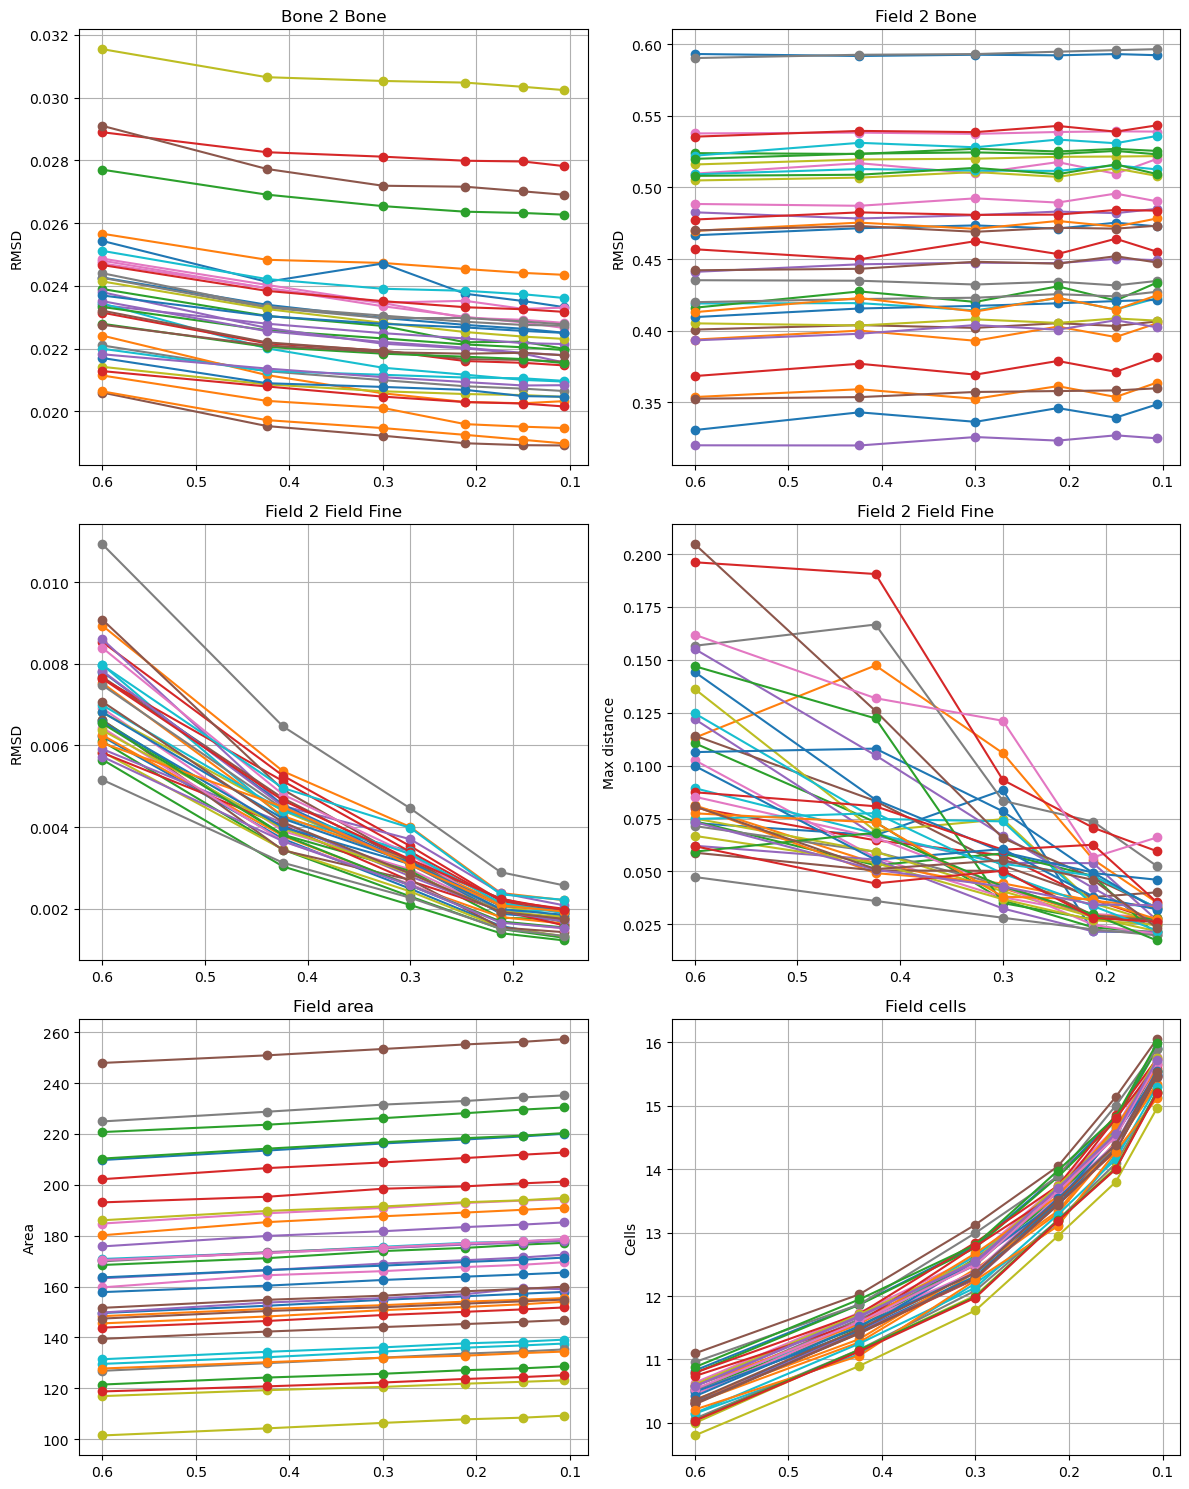

In [ ]:
# somtimes there are holes on edge of mesh where a cell should be or was in previous mesh
# max distance field 2 field can be affected by one point lying in one of the empty channels that form in the field

import matplotlib.pyplot as plt

subs_sides = df['subject'].unique()

# plot
fig, ax = plt.subplots(3, 2, figsize=(12, 15))
ax = ax.flatten()

for sub in subs_sides:

    sub_df = df[df['subject'] == sub]

    x = sub_df['fel']
    #x = sub_df['cells_field'][::-1]

    ax[0].plot(x, sub_df['rmsd_b2b_2way'], marker='o')
    ax[0].set_title('Bone 2 Bone')
    ax[0].set_ylabel('RMSD')

    ax[1].plot(x, sub_df['rmsd_f2b'], marker='o')
    ax[1].set_title('Field 2 Bone')
    ax[1].set_ylabel('RMSD')

    ax[2].plot(x, sub_df['rmsd_f2fine_2way'], marker='o')
    ax[2].set_title('Field 2 Field Fine')
    ax[2].set_ylabel('RMSD')

    ax[3].plot(x, sub_df['d_f2fine_max'], marker='o')
    ax[3].set_title('Field 2 Field Fine')
    ax[3].set_ylabel('Max distance')

    ax[4].plot(x, sub_df['area_field'], marker='o') # area slowly increases as it squeezes out every point up to 2mm
    ax[4].set_title('Field area')
    ax[4].set_ylabel('Area')

    ax[5].plot(x, np.log2(sub_df['cells_field']), marker='o')
    ax[5].set_title('Field cells')
    ax[5].set_ylabel('Cells')


for ax_i in ax:
    ax_i.grid()  
    ax_i.invert_xaxis()



plt.tight_layout()

print(FELs)

# should have measured the change in just the fine region of the bones - defo do this I think
    # if doing this start from scratch and just save all the height fields
# and maybe I write up the worst 95% and worst point for these measures.
    # maybe even the 99%
# could plot n cells with true values on y axis but make axis scale be like log 2

#### Absolute and rate of change in metrics

In [237]:
print(df.columns.to_list())

['subject', 'bones', 'fel', 'cells_bone_smooth', 'cells_bone', 'cells_field', 'points_bone_smooth', 'points_bone', 'points_field', 'area_bone_smooth', 'area_bone', 'area_field', 'vol_bone_smooth', 'vol_bone', 'rmsd_f2b', 'rmsd_b2b_ab', 'rmsd_b2b_ba', 'rmsd_b2b_2way', 'rmsd_f2fine_ab', 'rmsd_f2fine_ba', 'rmsd_f2fine_2way', 'rmsd_f2f_ab', 'rmsd_f2f_ba', 'rmsd_f2f_2way', 'd_f2f_ab_mean', 'd_f2f_ab_median', 'd_f2f_ab_max', 'd_f2f_ab_min', 'd_f2f_ab_std', 'd_f2f_ab_95', 'd_f2f_ab_5', 'd_f2f_ba_mean', 'd_f2f_ba_median', 'd_f2f_ba_max', 'd_f2f_ba_min', 'd_f2f_ba_std', 'd_f2f_ba_95', 'd_f2f_ba_5', 'd_f2fine_ab_mean', 'd_f2fine_ab_median', 'd_f2fine_ab_max', 'd_f2fine_ab_min', 'd_f2fine_ab_std', 'd_f2fine_ab_95', 'd_f2fine_ab_5', 'd_f2fine_ba_mean', 'd_f2fine_ba_median', 'd_f2fine_ba_max', 'd_f2fine_ba_min', 'd_f2fine_ba_std', 'd_f2fine_ba_95', 'd_f2fine_ba_5', 'Kmean_mean', 'Kmean_median', 'Kmean_max', 'Kmean_min', 'Kmean_std', 'Kmean_95', 'Kmean_5', 'Kgauss_mean', 'Kgauss_median', 'Kgauss_max

In [238]:
fels = df['fel'].unique()

stats = [
    'd_b2b_mean', 'd_b2b_median', 'd_b2b_std', 'd_b2b_95', 'd_b2b_5', 'd_b2b_max', 'd_b2b_min', 
    'd_f2f_mean', 'd_f2f_median', 'd_f2f_std', 'd_f2f_95', 'd_f2f_5', 'd_f2f_max', 'd_f2f_min', 
    'd_f2fine_mean', 'd_f2fine_median', 'd_f2fine_std', 'd_f2fine_95', 'd_f2fine_5', 'd_f2fine_max', 'd_f2fine_min',
    'd_f2b_mean', 'd_f2b_median', 'd_f2b_max', 'd_f2b_min', 'd_f2b_std', 'd_f2b_95', 'd_f2b_5',

    'Kmean_mean', 'Kmean_median', 'Kmean_max', 'Kmean_min', 'Kmean_std', 'Kmean_95', 'Kmean_5', 
    'Kgauss_mean', 'Kgauss_median', 'Kgauss_max', 'Kgauss_min', 'Kgauss_std', 'Kgauss_95', 'Kgauss_5',

    'rmsd_f2b', 'rmsd_b2b_2way', 'rmsd_f2fine_2way', 'rmsd_f2f_2way',

    'cells_bone_smooth', 'cells_bone', 'cells_field', 
    'points_bone_smooth', 'points_bone', 'points_field', 
    'area_bone_smooth', 'area_bone', 'area_field', 
    'vol_bone_smooth', 'vol_bone'
]

stat_select = [
    'rmsd_b2b_2way', 'rmsd_f2b', 'rmsd_f2fine_2way', 'd_f2fine_max', 'area_field', 'cells_field'
]

In [239]:
# compute absolute and relative change between edge length steps

df = df.sort_values(["subject", "fel"], ascending=False).copy()
change = df.groupby("subject")[stats]

abs_change = change.diff().add_suffix("_abs")
rel_change = change.pct_change().add_suffix("_rel")

df_change = pd.concat(
    [df[["subject", "fel"]].reset_index(drop=True),
     abs_change.reset_index(drop=True),
     rel_change.reset_index(drop=True)],
    axis=1,
)

[0.6, 0.424, 0.3, 0.212, 0.15, 0.106]


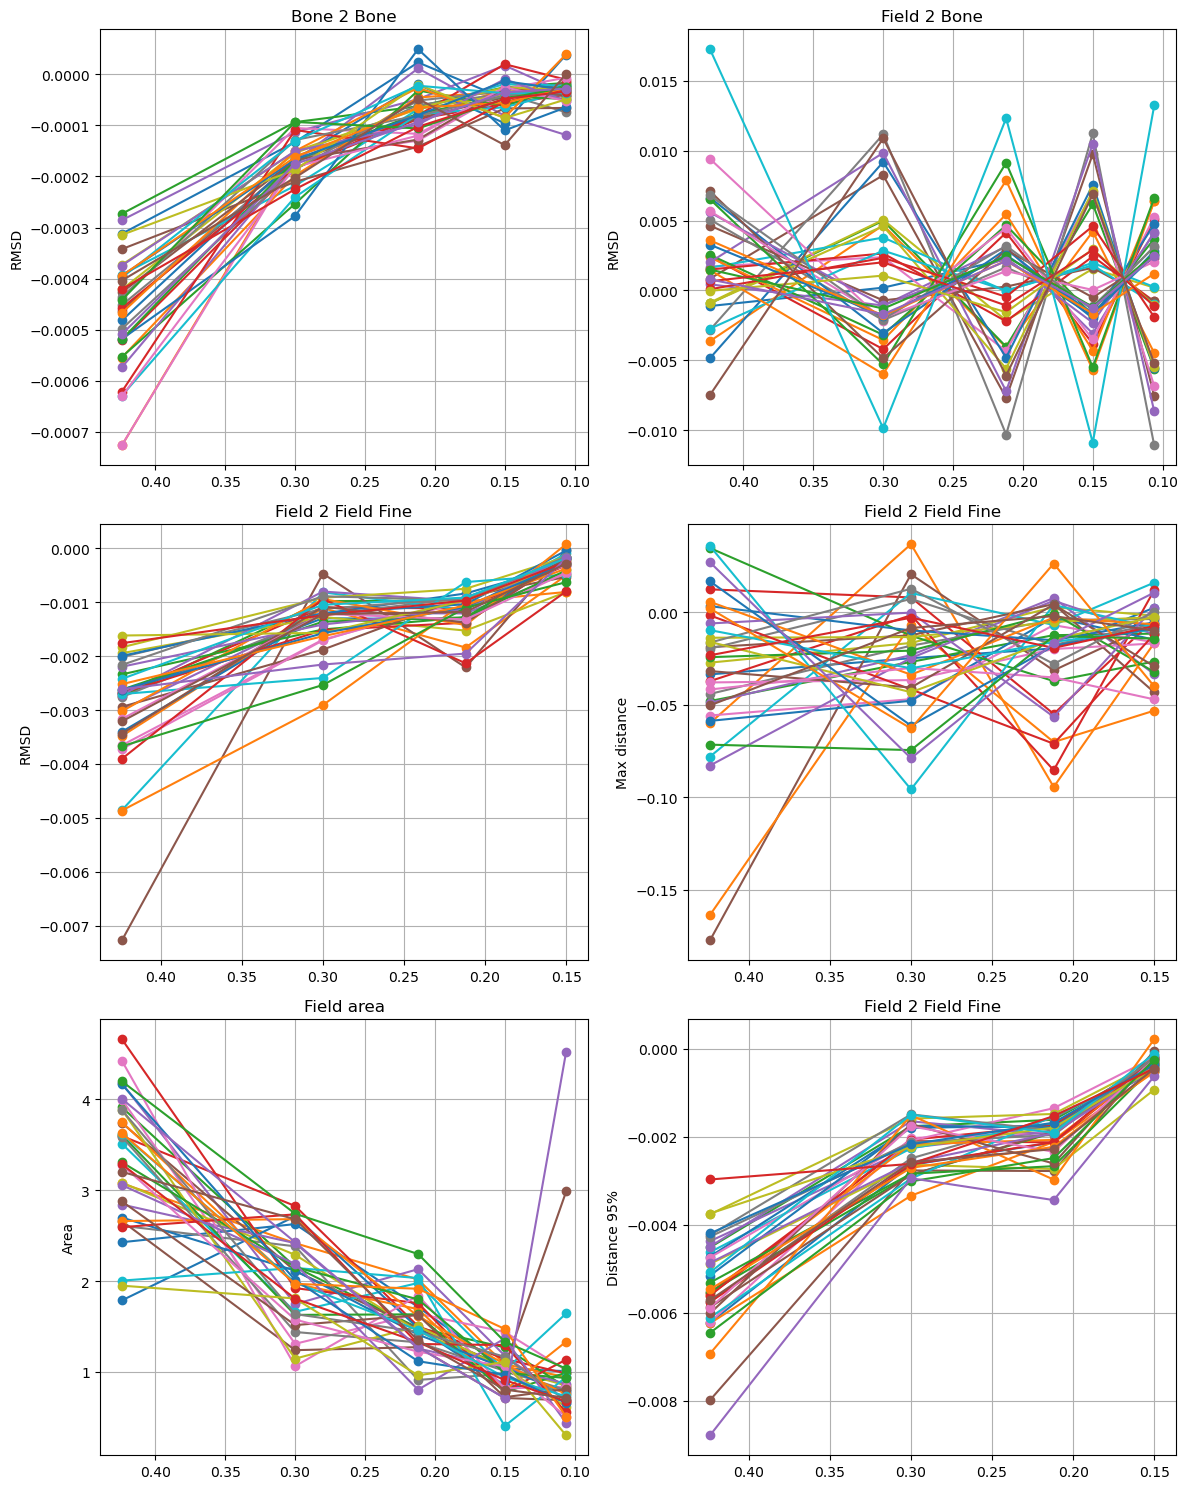

In [ ]:
# somtimes there are holes on edge of mesh where a cell should be or was in previous mesh
# max distance field 2 field can be affected by one point lying in one of the empty channels that form in the field

import matplotlib.pyplot as plt

select = 'abs' # rel for % change

subs_sides = df['subject'].unique()

# plot
fig, ax = plt.subplots(3, 2, figsize=(12, 15))
ax = ax.flatten()

for sub in subs_sides:

    sub_df = df_change[df_change['subject'] == sub]

    x = sub_df['fel']
    #x = sub_df['cells_field'][::-1]

    ax[0].plot(x, sub_df[f'rmsd_b2b_2way_{select}'], marker='o')
    ax[0].set_title('Bone 2 Bone')
    ax[0].set_ylabel('RMSD')

    ax[1].plot(x, sub_df[f'rmsd_f2b_{select}'], marker='o')
    ax[1].set_title('Field 2 Bone')
    ax[1].set_ylabel('RMSD')

    ax[2].plot(x, sub_df[f'rmsd_f2fine_2way_{select}'], marker='o')
    ax[2].set_title('Field 2 Field Fine')
    ax[2].set_ylabel('RMSD')

    ax[3].plot(x, sub_df[f'd_f2fine_max_{select}'], marker='o')
    ax[3].set_title('Field 2 Field Fine')
    ax[3].set_ylabel('Max distance')

    ax[4].plot(x, sub_df[f'area_field_{select}'], marker='o') # area slowly increases as it squeezes out every point up to 2mm
    ax[4].set_title('Field area')
    ax[4].set_ylabel('Area')

    ax[5].plot(x, sub_df[f'd_f2fine_95_{select}'], marker='o')
    ax[5].set_title('Field 2 Field Fine')
    ax[5].set_ylabel('Distance 95%')


for ax_i in ax:
    ax_i.grid()  
    ax_i.invert_xaxis()



plt.tight_layout()

print(FELs)

# need to plot absolutes of the ones that oscilate

### Runtime
 - Already have per subject runtimes for 2Dmesh so just need to get runtimes for cartilage mesh
 - Then will choose fine_edge_length based on combination of runtime and above plots
### fine_edge_length = 0.2

In [242]:
runtime_file = 'outputs/cartilage_height_field/reports/runtimes.jsonl'
runtimes = pd.read_json(runtime_file, lines=True)

In [243]:
# 2Dmesh runtime - per subject (both tpm and mc1 together)
param_file2d = "full_params-9.json"
runtimes_2d = runtimes[runtimes['full_params']==param_file2d].copy()
runtimes_2d

,timestamp,full_params,subject,bones,step,input_json,run_ids,runtime
153,2026-03-27 15:25:05,full_params-9.json,50037L,tpm-mc1,2Dmesh,outputs/cartilage_height_field/params/2Dmesh/0...,[0],6.396010
154,2026-03-27 15:25:11,full_params-9.json,50037L,tpm-mc1,2Dmesh,outputs/cartilage_height_field/params/2Dmesh/1...,[1],6.580151
155,2026-03-27 15:25:18,full_params-9.json,50037L,tpm-mc1,2Dmesh,outputs/cartilage_height_field/params/2Dmesh/2...,[2],6.639714
156,2026-03-27 15:25:25,full_params-9.json,50037L,tpm-mc1,2Dmesh,outputs/cartilage_height_field/params/2Dmesh/3...,[3],6.814119
157,2026-03-27 15:25:32,full_params-9.json,50037L,tpm-mc1,2Dmesh,outputs/cartilage_height_field/params/2Dmesh/4...,[4],7.135070
...,...,...,...,...,...,...,...,...
470,2026-03-27 15:54:46,full_params-9.json,14685R,tpm-mc1,2Dmesh,outputs/cartilage_height_field/params/2Dmesh/2...,[2],6.317454
471,2026-03-27 15:54:52,full_params-9.json,14685R,tpm-mc1,2Dmesh,outputs/cartilage_height_field/params/2Dmesh/3...,[3],6.400798
472,2026-03-27 15:54:59,full_params-9.json,14685R,tpm-mc1,2Dmesh,outputs/cartilage_height_field/params/2Dmesh/4...,[4],6.806180
473,2026-03-27 15:55:06,full_params-9.json,14685R,tpm-mc1,2Dmesh,outputs/cartilage_height_field/params/2Dmesh/5...,[5],7.313943


In [313]:
(runtimes_2d.groupby('subject').count()==7).all()

timestamp      True
full_params    True
bones          True
step           True
input_json     True
run_ids        True
runtime        True
dtype: bool

#### Get cartilage runtimes for both bones

In [126]:
import subprocess
path_MeshPipeline_main = '../../../../MeshPipeline/main.py'
subprocess.run(["python", path_MeshPipeline_main])


Updating parameters.json
	Wrote /Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/MeshPipeline/set_parameters/parameters.json



SUBJECT: 50037L
	BONES: tpm-mc1
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 1.514s - ok
			RUN ID: -1
			Runtime: 1.534s - ok
			RUN ID: -2
			Runtime: 1.497s - ok
			RUN ID: -3
			Runtime: 1.514s - ok
			RUN ID: -4
			Runtime: 1.529s - ok
			RUN ID: -5
			Runtime: 1.606s - ok
		STEP: cartilage
			RUN ID: -0-0
			Runtime: 1.522s - ok
			RUN ID: -1-0
			Runtime: 1.479s - ok
			RUN ID: -2-0
			Runtime: 1.600s - ok
			RUN ID: -3-0
			Runtime: 1.520s - ok
			RUN ID: -4-0
			Runtime: 1.484s - ok
			RUN ID: -5-0
			Runtime: 1.509s - ok
	BONES: mc1-tpm
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 1.511s - ok
			RUN ID: -1
			Runtime: 1.512s - ok
			RUN ID: -2
			Runtime: 1.522s - ok
			RUN ID: -3
			Runtime: 1.506s - ok
			RUN ID: -4
			Runtime: 1.565s - ok
			RUN ID: -5
			Runtime: 1.600s - ok
		STE

CompletedProcess(args=['python', '../../../../MeshPipeline/main.py'], returncode=0)

#### Sort cartilage runtimes
 - Some were generated by params-10
 - All are present in params-11 but were previous ones were not overwritten
 - so need to take max if exist in both else take params-11
 - Only consider first 6 for each cos some have multiple or partial runs for params-10

In [294]:
# cartilage runtimes
param_file_cart1 = "full_params-10.json"
param_file_cart2 = "full_params-11.json"

runtimes_cart1 = runtimes[(runtimes['step']=='cartilage') & (runtimes['full_params']==param_file_cart1)].copy()
runtimes_cart2 = runtimes[(runtimes['step']=='cartilage') & (runtimes['full_params']==param_file_cart2)].copy()

In [362]:
fels = [0.6, 0.424, 0.3, 0.212, 0.15, 0.106]
subjects = runtimes_cart2.subject.unique()
print(len(subjects), 'subjects')
bones = ['tpm-mc1', 'mc1-tpm']

rts = []
for subject in subjects:
    for bs in bones:
        a = runtimes_cart1[(runtimes_cart1['subject']==subject)&(runtimes_cart1['bones']==bs)].iloc[:6]
        b = runtimes_cart2[(runtimes_cart2['subject']==subject)&(runtimes_cart2['bones']==bs)].iloc[:6]

        for i in range(len(fels)):
            try: # if it is in both take max runtime (cos that's the one that actually generated it)
                rts.append({
                    'runtime': np.max((a.iloc[i]['runtime'], b.iloc[i]['runtime']), axis=0),
                    'subject': subject,
                    'bones': bs,
                    'fel': fels[i]
                })
            except: # else it was only generated in params-11
                rts.append({
                    'runtime': b.iloc[i]['runtime'],
                    'subject': subject,
                    'bones': bs,
                    'fel': fels[i]
                })

46 subjects


In [344]:
runtimes_cart = pd.DataFrame(rts)
print((runtimes_cart.groupby(['subject', 'bones']).count() == 6).all())

runtime    True
fel        True
dtype: bool


In [345]:
runtimes_cart

,runtime,subject,bones,fel
0,2.021942,50037L,tpm-mc1,0.600
1,2.558638,50037L,tpm-mc1,0.424
2,3.619321,50037L,tpm-mc1,0.300
3,7.346273,50037L,tpm-mc1,0.212
4,16.525090,50037L,tpm-mc1,0.150
...,...,...,...,...
547,2.792356,14685R,mc1-tpm,0.424
548,3.618267,14685R,mc1-tpm,0.300
549,7.195854,14685R,mc1-tpm,0.212
550,14.033747,14685R,mc1-tpm,0.150


#### error / interference mask
 - mask of runs that either interferred or errored

In [470]:
error_file = 'outputs/cartilage_height_field/reports/errors.jsonl'
inter_file = 'outputs/cartilage_height_field/reports/interference.jsonl'
errors = pd.read_json(error_file, lines=True)
inters = pd.read_json(inter_file, lines=True)
# only need params-11 results cos that ran all of them so if it errored or interferred it just did it again in 11
errors = errors[errors['full_params']=='full_params-11.json'].copy()
inters = inters[inters['full_params']=='full_params-11.json'].copy()

In [471]:
mask = np.ones(len(runtimes_cart), dtype=bool)

for i in range(len(errors)):
    row = errors.iloc[i]
    sub = row['subject']
    bn = row['bones']
    run_id = int(row['run_ids'][0])

    cart_id = runtimes_cart[(runtimes_cart['subject']==sub)&(runtimes_cart['bones']==bn)].iloc[run_id].name
    mask[cart_id] = False
    # set pair to false cos later plot sum of their runtimes
    other_bn = bn.split('-')[1] + '-' + bn.split('-')[0] 
    cart_id2 = runtimes_cart[(runtimes_cart['subject']==sub)&(runtimes_cart['bones']==other_bn)].iloc[run_id].name
    mask[cart_id2] = False

for i in range(len(inters)):
    row = inters.iloc[i]
    sub = row['subject']
    bn = row['bones']
    run_id = int(row['run_ids'][0])

    cart_id = runtimes_cart[(runtimes_cart['subject']==sub)&(runtimes_cart['bones']==bn)].iloc[run_id].name
    mask[cart_id] = False
    # set pair to false cos later plot sum of their runtimes
    other_bn = bn.split('-')[1] + '-' + bn.split('-')[0] 
    cart_id2 = runtimes_cart[(runtimes_cart['subject']==sub)&(runtimes_cart['bones']==other_bn)].iloc[run_id].name
    mask[cart_id2] = False


In [ ]:
# df of all runs with no errors or interference
runtimes_cart_ok = runtimes_cart[mask]

#### Plot

34 subjects


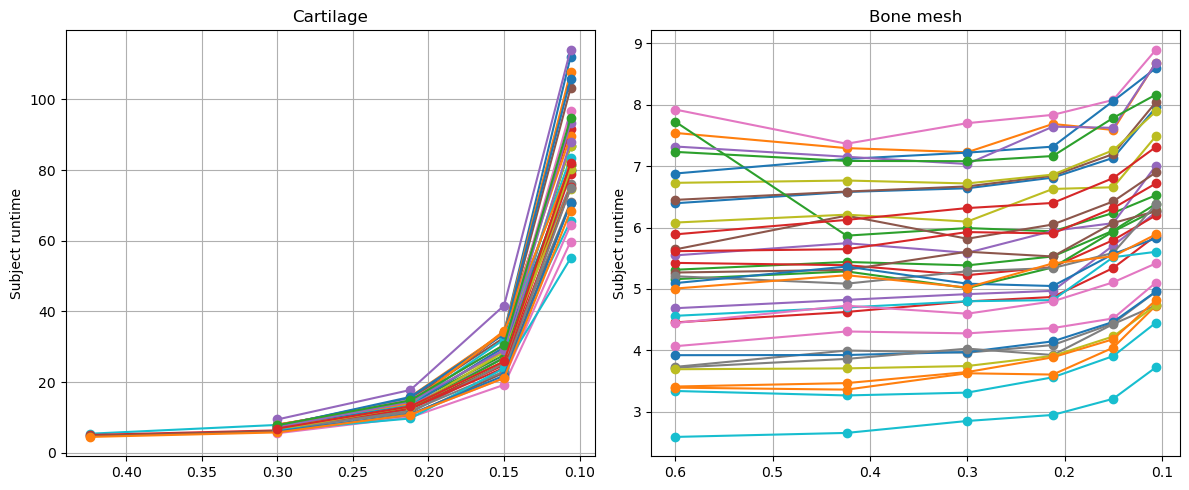

In [ ]:
fels = [0.6, 0.424, 0.3, 0.212, 0.15, 0.106]
import matplotlib.pyplot as plt

select = 'abs' # rel for % change

subs_sides = runtimes_cart_ok.subject.unique()
print(len(subs_sides), 'subjects')

# plot
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax = ax.flatten()

for sub in subs_sides:

    # cartilage 
    sub_df = runtimes_cart_ok[runtimes_cart_ok['subject'] == sub]
    y = sub_df[sub_df['bones']=='tpm-mc1']['runtime'].values + sub_df[sub_df['bones']=='mc1-tpm']['runtime'].values
    x = sub_df[sub_df['bones']=='tpm-mc1']['fel']

    ax[0].plot(x, y, marker='o')
    ax[0].set_title('Cartilage')
    ax[0].set_ylabel('Edge length')
    ax[0].set_ylabel('Subject runtime')

    # 2Dmesh
    sub_df = runtimes_2d[runtimes_2d['subject'] == sub]
    y = sub_df[sub_df['bones']=='tpm-mc1']['runtime'].values[:6]
    x = fels
    
    ax[1].plot(x, y, marker='o')
    ax[1].set_title('Bone mesh')
    ax[1].set_ylabel('Edge length')
    ax[1].set_ylabel('Subject runtime')


for ax_i in ax:
    ax_i.grid()  
    ax_i.invert_xaxis()

plt.tight_layout()

 - Can later run the same thing for the 3Dmesh for one subject (only look at effect on mesh generation not optimisation), (do every edge lenth) for whichever subject has the longest runtime and no issues, and plot that to show effect it has on 3Dmesh
    - 0.2 will be fine cos generation time is of same order of magnitude or much lower than optimisation time so no drama.

# How many isotropic_remeshing iterations?
 - run for [1, 2, 4, 8, 16] iterations
 - measure difference between them

 - ran again - no overwrite for [1, 2, 4, 8, 16, 32, 64, 128]

Saved to outputs/Iterations

In [394]:
import subprocess
path_MeshPipeline_main = '../../../../MeshPipeline/main.py'
subprocess.run(["python", path_MeshPipeline_main])


Updating parameters.json
	Wrote /Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/MeshPipeline/set_parameters/parameters.json



SUBJECT: 50037L
	BONES: tpm-mc1
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 1.486s - ok
			RUN ID: -1
			Runtime: 1.465s - ok
			RUN ID: -2
			Runtime: 1.567s - ok
			RUN ID: -3
			Runtime: 1.553s - ok
			RUN ID: -4
			Runtime: 1.564s - ok
			RUN ID: -5
			Runtime: 8.539s - ok
			RUN ID: -6
			Runtime: 10.471s - ok
			RUN ID: -7
			Runtime: 14.751s - ok

SUBJECT: 50090R
	BONES: tpm-mc1
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 1.509s - ok
			RUN ID: -1
			Runtime: 1.504s - ok
			RUN ID: -2
			Runtime: 1.490s - ok
			RUN ID: -3
			Runtime: 1.484s - ok
			RUN ID: -4
			Runtime: 1.526s - ok
			RUN ID: -5
			Runtime: 7.300s - ok
			RUN ID: -6
			Runtime: 9.010s - ok
			RUN ID: -7
			Runtime: 12.781s - ok

SUBJECT: 15294R
	BONES: tpm-mc1
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 1.506s - ok
			RU

CompletedProcess(args=['python', '../../../../MeshPipeline/main.py'], returncode=0)

In [395]:
from pathlib import Path
output_root = Path('outputs/Iterations')
bone_arbone = 'tpm-mc1'
subject_sideL = '14548R'
run_id = '-3'

bone_remesh = pv.read(f'{output_root}/meshes/{subject_sideL}/{bone_arbone}/2Dmesh/bone_remesh{run_id}.obj')

In [393]:
bone_remesh.plot()

Widget(value='<iframe src="http://localhost:53297/index.html?ui=P_0x36796bbf0_68&reconnect=auto" class="pyvist…

In [398]:
from pathlib import Path
import pyvista as pv
import pandas as pd
import numpy as np
from tqdm import tqdm

def combine_rmsd(rmsd_ab, rmsd_ba):
    return float(np.sqrt(0.5 * (rmsd_ab**2 + rmsd_ba**2)))

def compute_dists(mesh, points):
    _, ps = mesh.find_closest_cell(points, return_closest_point=True)
    return np.linalg.norm(points - ps, axis=1)

def compute_rmsd(dists):
    return float(np.sqrt(np.mean(dists**2)))


iters = [1, 2, 4, 8, 16, 32, 64, 128]

path = Path('outputs/Iterations/meshes')

subs_sides = [p.name for p in path.iterdir() if p.is_dir()]
bones = ['tpm-mc1', 'mc1-tpm']

data = []
for sub in tqdm(subs_sides):
    for bn in bones:
        b = pv.read(path / f'{sub}/{bn}/2Dmesh/bone_remesh-{len(iters)-1}.obj')
        for i in range(len(iters)-1):
            a = pv.read(path / f'{sub}/{bn}/2Dmesh/bone_remesh-{i}.obj')

            ab = compute_dists(a, b.points)
            ba = compute_dists(b, a.points)
            rmsd = combine_rmsd( 
                compute_rmsd(ab), 
                compute_rmsd(ba), 
                )
            data.append({
                'sub': sub,
                'bone': bn.split('-')[0],
                'iters': iters[i],
                'rmsd': rmsd,
                'd_mean': np.mean(np.hstack((ab, ba))),
                'd_95': np.percentile(np.hstack((ab, ba)), 95),
                'd_max': np.max([ab.max(), ba.max()])
            })
#pd.DataFrame(data).to_csv('IsotropicRemeshIterations.csv', index=False)

100%|██████████| 46/46 [02:39<00:00,  3.46s/it]


In [400]:
import pandas as pd

df = pd.read_csv('IsotropicRemeshIterations.csv')
df

,sub,bone,iters,rmsd,d_mean,d_95,d_max
0,14818R,tpm,1,0.005409,0.002553,0.010485,0.089019
1,14818R,tpm,2,0.005352,0.002539,0.010500,0.085314
2,14818R,tpm,4,0.005295,0.002514,0.010380,0.075362
3,14818R,tpm,8,0.005241,0.002487,0.010226,0.069668
4,14818R,tpm,16,0.005160,0.002467,0.010088,0.077838
...,...,...,...,...,...,...,...
639,15283R,mc1,4,0.003902,0.002161,0.008612,0.048773
640,15283R,mc1,8,0.003700,0.002079,0.008218,0.043745
641,15283R,mc1,16,0.003420,0.001951,0.007592,0.033972
642,15283R,mc1,32,0.003023,0.001755,0.006691,0.034380


46 subjects


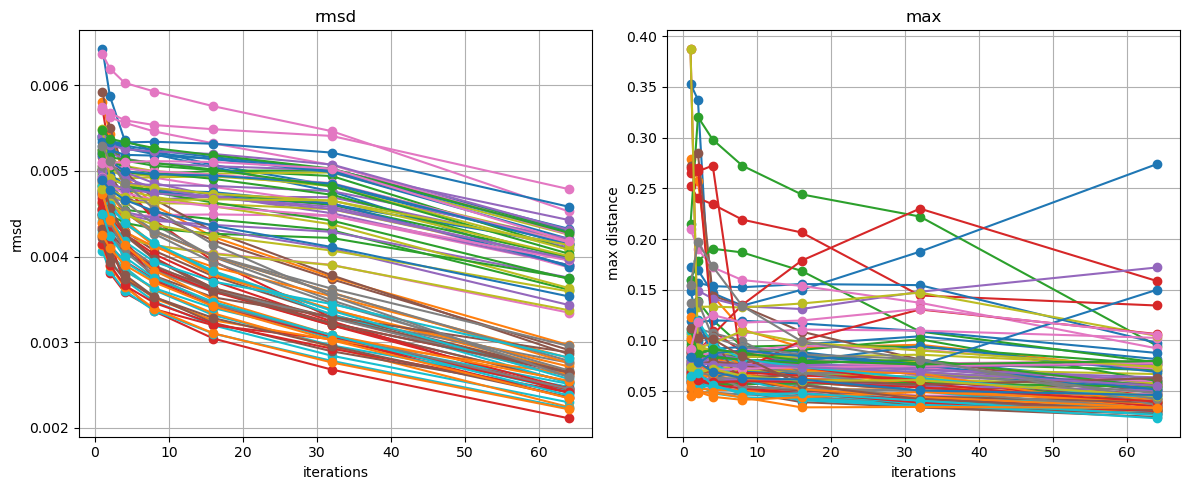

In [412]:
import matplotlib.pyplot as plt

bones = ['tpm', 'mc1']
subs_sides = df['sub'].unique()
print(len(subs_sides), 'subjects')

iters = df['iters'].unique()

# plot
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax = ax.flatten()

for sub in subs_sides:
    sub_df = df[df['sub'] == sub]
    for bone in bones:

        bone_df = sub_df[sub_df['bone'] == bone]

        ax[0].plot(iters, bone_df['rmsd'], marker='o')
        ax[0].set_title('rmsd')
        ax[0].set_xlabel('iterations')
        ax[0].set_ylabel('rmsd')
        
        ax[1].plot(iters, bone_df['d_max'], marker='o')
        ax[1].set_title('max')
        ax[1].set_xlabel('iterations')
        ax[1].set_ylabel('max distance')


for ax_i in ax:
    ax_i.grid()  

plt.tight_layout()

In [460]:
iters = [1, 2, 4, 8, 16, 32, 64, 128]

run_df = pd.read_json('outputs/Iterations/reports/runtimes.jsonl', lines=True)
run_df0 = run_df[run_df['full_params'] == 'full_params.json'].copy()
run_df1 = run_df[run_df['full_params'] == 'full_params-1.json'].copy()

subs_sides = run_df['subject'].unique()
print(len(subs_sides), 'subjects')

run_df0['iters'] = np.tile(iters[:5], len(subs_sides))
run_df1['iters'] = np.tile(iters, len(subs_sides))
run_df1 = run_df1[run_df1['iters'] > 16].copy()

run_df = pd.concat((run_df0, run_df1), axis=0).sort_values(['subject', 'iters']).reset_index()

46 subjects


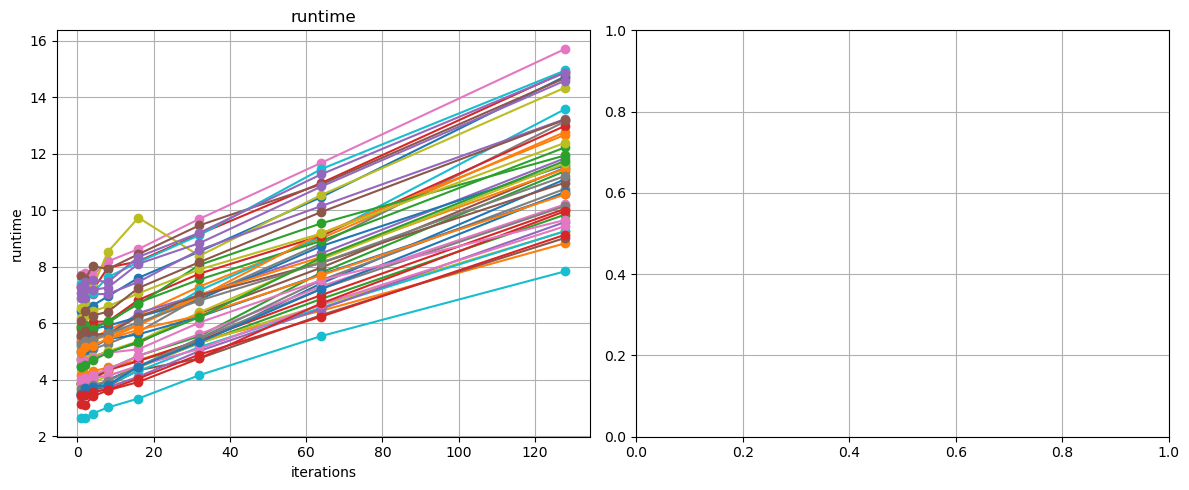

In [467]:
import matplotlib.pyplot as plt

# plot
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax = ax.flatten()

for sub in subs_sides:
    sub_df = run_df[run_df['subject'] == sub]

    ax[0].plot(iters, sub_df['runtime'], marker='o')
    ax[0].set_title('runtime')
    ax[0].set_xlabel('iterations')
    ax[0].set_ylabel('runtime')


for ax_i in ax:
    ax_i.grid()  

plt.tight_layout()